<a href="https://colab.research.google.com/github/pierrot73/GenAIBootCamp/blob/Bootcamp/Wekk_6_Day1_DC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk import pos_tag, ne_chunk
import spacy
nlp = spacy.load('en_core_web_sm')
# Télécharger les ressources nécessaires de NLTK
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('maxent_ne_chunker_tab')
# Charger le modèle pré-entraîné de spaCy
nlp = spacy.load('en_core_web_sm')
# :un: Fonction pour charger et nettoyer les textes
def load_texts(urls):
    corpus = []
    for url in urls:
        try:
            response = requests.get(url)
            response.raise_for_status()
            text = response.text
            # Supprimer les crédits en cherchant les mots clés
            start = text.find('START OF')
            end = text.find('END OF')
            if start != -1 and end != -1:
                text = text[start:end]
            # Nettoyer les caractères non-mots
            cleaned_text = re.sub(r'\W+', ' ', text)
            corpus.append(cleaned_text)
        except requests.exceptions.RequestException as e:
            print(f"Erreur lors de la récupération de {url} : {e}")
    return corpus
# :inbox: URLs des textes à charger
urls = [
    'https://www.gutenberg.org/cache/epub/11/pg11.txt',       # Alice's Adventures in Wonderland
    'https://www.gutenberg.org/cache/epub/12/pg12.txt',       # Through the Looking-Glass
    'https://www.gutenberg.org/cache/epub/29042/pg29042.txt'  # A Tangled Tale
]
# :reçu: Charger les textes
corpus = load_texts(urls)
# :deux: Afficher les 200 premiers caractères de chaque texte nettoyé
print("\n:étoile2: Premier aperçu des textes :")
for i, text in enumerate(corpus):
    print(f"\nTexte {i+1} (200 caractères) :\n{text[:200]}")
# :trois: Tokenisation
print("\n:abc: Première tokenisation :")
tokenized_texts = [word_tokenize(text.lower()) for text in corpus]
for i, tokens in enumerate(tokenized_texts):
    print(f"\nTexte {i+1} - 150 premiers tokens :\n{tokens[:150]}")
# :quatre: Suppression des stopwords
stop_words = set(stopwords.words('english'))
filtered_texts = [[token for token in tokens if token not in stop_words] for tokens in tokenized_texts]
print("\n:interdit: Vérification des stopwords retirés :")
stopwords_exemples = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves']
for word in stopwords_exemples:
    for i, tokens in enumerate(filtered_texts):
        count = tokens.count(word)
        print(f"'{word}' dans texte {i+1} : {count}")
# :cinq: Stemming avec PorterStemmer
stemmer = PorterStemmer()
print("\n:pousse: Stemming (50 premiers stems) :")
for i, tokens in enumerate(filtered_texts):
    stemmed = [stemmer.stem(token) for token in tokens[:50]]
    print(f"\nTexte {i+1} stems :\n{stemmed}")
# :six: Lemmatization avec spaCy
print("\n:feuilles: Lemmatization (50 premiers lemmes) :")
for i, text in enumerate(corpus):
    doc = nlp(text.lower())
    lemmatized = [token.lemma_ for token in doc if token.is_alpha][:50]
    print(f"\nTexte {i+1} lemmes :\n{lemmatized}")
# :sept: Analyse des différences entre stemming et lemmatization
print("\n:livres: Différences entre stemming et lemmatisation :")
print("""
Le stemming réduit les mots à leur racine brute (souvent déformée), utile pour les moteurs de recherche.
Ex: 'running' → 'run', 'better' → 'better'
La lemmatisation identifie la forme canonique du mot, en tenant compte du contexte grammatical.
Ex: 'running' → 'run', 'better' → 'good'
Donc, lemmatisation est plus précise mais plus lente.
""")
# :huit: Tags grammaticaux (POS) avec NLTK
print("\n:étiquette: POS Tags :")
for i, tokens in enumerate(tokenized_texts):
    pos_tags = pos_tag(tokens[:50])
    print(f"\nTexte {i+1} POS Tags :\n{pos_tags}")
# :neuf: Reconnaissance d'entités nommées avec NLTK
print("\n:cerveau: Entités nommées :")
for i, tokens in enumerate(tokenized_texts):
    entities = ne_chunk(pos_tag(tokens[:100]))
    print(f"\nTexte {i+1} Entités :\n{entities}")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...



:étoile2: Premier aperçu des textes :

Texte 1 (200 caractères) :
START OF THE PROJECT GUTENBERG EBOOK ALICE S ADVENTURES IN WONDERLAND Illustration Alice s Adventures in Wonderland by Lewis Carroll THE MILLENNIUM FULCRUM EDITION 3 0 Contents CHAPTER I Down the Rabb

Texte 2 (200 caractères) :
START OF THE PROJECT GUTENBERG EBOOK THROUGH THE LOOKING GLASS Illustration THROUGH THE LOOKING GLASS And What Alice Found There By Lewis Carroll The Millennium Fulcrum Edition 1 7 DRAMATIS PERSONÆ _A

Texte 3 (200 caractères) :
START OF THE PROJECT GUTENBERG EBOOK A TANGLED TALE Produced by Chris Curnow Carla Foust Lindy Walsh and the Online Distributed Proofreading Team at https www pgdp net Music transcribed by Linda Canto

:abc: Première tokenisation :

Texte 1 - 150 premiers tokens :
['start', 'of', 'the', 'project', 'gutenberg', 'ebook', 'alice', 's', 'adventures', 'in', 'wonderland', 'illustration', 'alice', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millenni

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


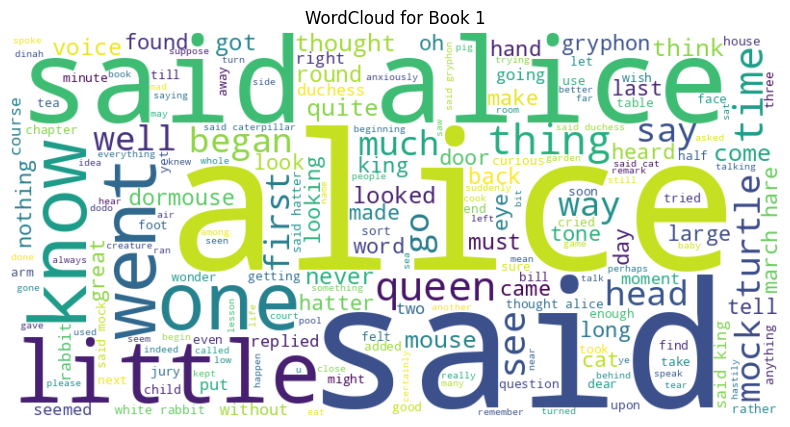

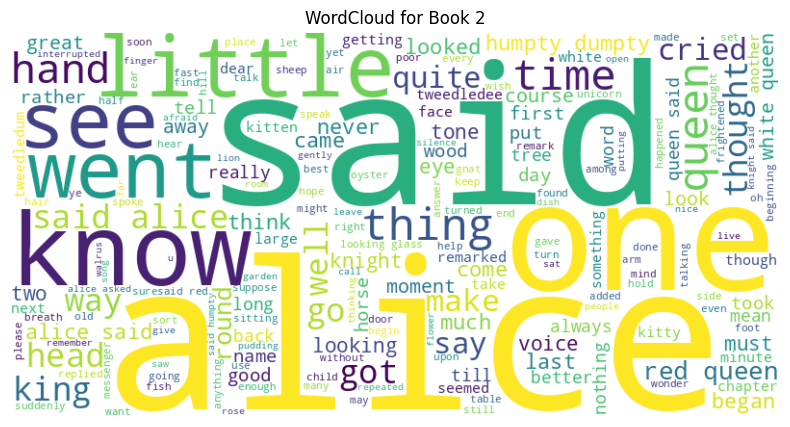

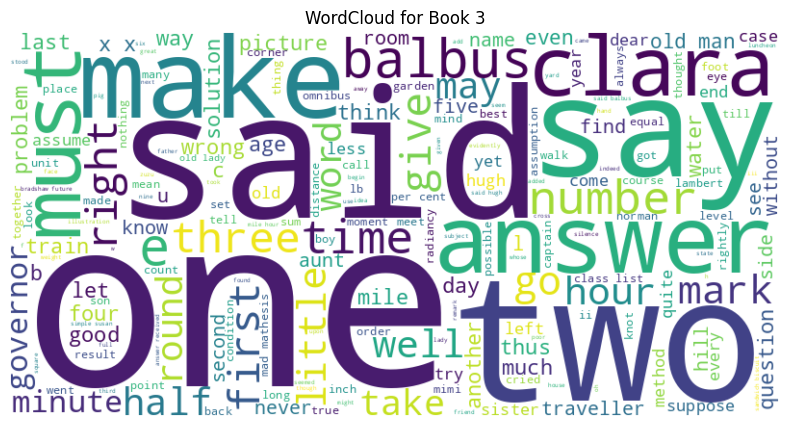

Top 5 most frequent words: [('said', np.int64(1067)), ('alice', np.int64(871)), ('one', np.int64(458)), ('queen', np.int64(288)), ('little', np.int64(284))]
Bag of Words for Book 0:
Index: 3, Word: abide, Count: 1
Index: 4, Word: able, Count: 1
Index: 7, Word: absence, Count: 1
Index: 12, Word: absurd, Count: 2
Index: 19, Word: acceptance, Count: 1
Index: 21, Word: accident, Count: 2
Index: 23, Word: accidentally, Count: 1
Index: 29, Word: account, Count: 2
Index: 30, Word: accounting, Count: 1
Index: 32, Word: accusation, Count: 1
Index: 33, Word: accustomed, Count: 1
Index: 34, Word: ache, Count: 1
Index: 40, Word: across, Count: 5
Index: 41, Word: act, Count: 1
Index: 44, Word: actually, Count: 1
Index: 47, Word: ada, Count: 1
Index: 49, Word: added, Count: 23
Index: 51, Word: adding, Count: 1
Index: 57, Word: addressed, Count: 2
Index: 58, Word: addressing, Count: 1
Index: 62, Word: adjourn, Count: 1
Index: 73, Word: adoption, Count: 1
Index: 76, Word: advance, Count: 3
Index: 77, 

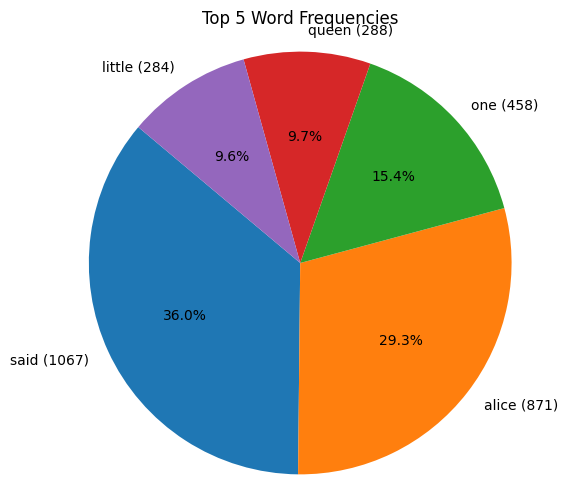


Analysis:
Are the words informative?
→ If the words are common like 'said', 'one', 'like' they may not add insight.
→ If they are character names or topic-specific (e.g., 'whale' in Moby Dick), they are more meaningful.
→ Consider removing domain-general stopwords again or using TF-IDF for more insight.


In [ ]:
import requests
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk import pos_tag, ne_chunk
import spacy
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.stem import WordNetLemmatizer
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# Télécharger les ressources nécessaires de NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('wordnet')

# Charger le modèle pré-entraîné de spaCy
nlp = spacy.load('en_core_web_sm')

# :un: Fonction pour charger et nettoyer les textes
def load_texts(urls):
    corpus = []
    for url in urls:
        try:
            response = requests.get(url)
            response.raise_for_status()
            text = response.text
            # Supprimer les crédits en cherchant les mots clés
            start = text.find('START OF')
            end = text.find('END OF')
            if start != -1 and end != -1:
                text = text[start:end]
            # Nettoyer les caractères non-mots
            cleaned_text = re.sub(r'\W+', ' ', text)
            corpus.append(cleaned_text)
        except requests.exceptions.RequestException as e:
            print(f"Erreur lors de la récupération de {url} : {e}")
    return corpus

# :inbox: URLs des textes à charger
urls = [
    'https://www.gutenberg.org/cache/epub/11/pg11.txt',       # Alice's Adventures in Wonderland
    'https://www.gutenberg.org/cache/epub/12/pg12.txt',       # Through the Looking-Glass
    'https://www.gutenberg.org/cache/epub/29042/pg29042.txt'  # A Tangled Tale
]

# :reçu: Charger les textes
books = load_texts(urls)

def preprocess_text(text):
    tokens = nltk.word_tokenize(text.lower())
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [word for word in tokens if word not in stopwords.words('english')]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

preprocessed_books = [preprocess_text(book) for book in books]

# Plot wordclouds
for i, book in enumerate(preprocessed_books):
    wc = WordCloud(width=800, height=400, background_color='white').generate(book)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud for Book {i+1}")
    plt.show()

#Step 2: BoW + Five Most Frequent Words

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(preprocessed_books)

# Sum word counts over all documents
word_counts = X.toarray().sum(axis=0)
word_freq = dict(zip(vectorizer.get_feature_names_out(), word_counts))

# Get top 5 frequent words
top_5 = Counter(word_freq).most_common(5)
print("Top 5 most frequent words:", top_5)
 #Step 3: Print BoW Details

# Example: printing word frequencies for Book 0
book_index = 0
book_vector = X[book_index].toarray()[0]

print(f"Bag of Words for Book {book_index}:")
for idx, count in enumerate(book_vector):
    if count > 0:
        word = vectorizer.get_feature_names_out()[idx]
        print(f"Index: {idx}, Word: {word}, Count: {count}")
 #Step 4: Pie Chart of Top 5 Words

labels = [f"{word} ({count})" for word, count in top_5]
sizes = [count for _, count in top_5]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title("Top 5 Word Frequencies")
plt.axis('equal')
plt.show()
#Step 5: Analysis

print("\nAnalysis:")
print("Are the words informative?")
print("→ If the words are common like 'said', 'one', 'like' they may not add insight.")
print("→ If they are character names or topic-specific (e.g., 'whale' in Moby Dick), they are more meaningful.")

print("→ Consider removing domain-general stopwords again or using TF-IDF for more insight.")